## 1. Common Functions (無論三種方法的哪種都需要執行)

### Initial Setting

In [1]:
degree  = 3 #擬合維度(最高項次方數, 項數為degree+1)
lambda_val = 0.1 #正則化強度 (用於Closed-form LSE Approach和Steepest Descent Method)
iter_num = 10000 #訓練圈數 (用於Steepest Descent Method和Newton Method)

### Matrix Operations

In [2]:
import numpy as np
def Indentity_Matrix_Formulation(dim): #Identity Matrix產生
    I = np.zeros((dim,dim))
    for i in range(dim):
        I[i][i]=1
    return I

def Matrix_Transpose(A): #轉置矩陣
    dim1 = len(A)
    dim2 = len(A[0])
    A_T = []
    for i in range(dim2):
        A_T.append([])
        for j in range(dim1):
            A_T[-1].append(A[j][i])
    return np.array(A_T)

def Matrix_Inversion(A): #反矩陣
    A = A.copy()
    dim = A.shape[0]
    I = Indentity_Matrix_Formulation(dim)
    
    #第一次操作: 從上至下
    for i in range(dim-1):
        element = A[i][i]
        for j in range(i+1,dim):
            Target = A[j][i]
            Ratio = -Target/element
            A[j] = A[j]+A[i]*Ratio
            I[j] = I[j]+I[i]*Ratio
    #第二次操作: 從下至上
    
    for i in range(dim-1,0,-1):
        element = A[i][i]
        for j in range(i-1,-1,-1):
            Target = A[j][i]
            Ratio = -Target/element
            A[j] = A[j]+A[i]*Ratio
            I[j] = I[j]+I[i]*Ratio
    
    #第三次操作: 化為1 
    for i in range(dim):
        Target = A[i][i]
        I[i] = I[i]/Target 
             
    return I

def Matrix_Multiplication(A,B): #矩陣相乘
    AB = np.zeros((A.shape[0],B.shape[1]))
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            sum = 0
            for k in range(A.shape[1]):
                sum += A[i][k]*B[k][j]
            AB[i][j] = sum
    return AB

### Data Read In

In [3]:
'''
依據題目pdf給的提示, 推測應為txt file, 以下使用txt讀取方法
'''
with open('Test_Data.txt', 'r', encoding='utf-8') as file:
    XY_collector = []
    for line in file:
        XY_collector.append([])
        str_x = ''
        str_y = ''
        first_num = True
        for cha in line:
            if cha!=',':
                if first_num==True:
                    str_x+=cha
                else:
                    str_y+=cha
            else:
                first_num=False
        XY_collector[-1].append(int(str_x))
        XY_collector[-1].append(int(str_y))
print(XY_collector) #XY_collector應該裝著(X,Y) pair.

[[-1, 12], [0, 27], [3, 1], [6, 85]]


### Data Transformation

In [4]:
def build_design_matrix(A, degree):
    return np.array([[x**d for d in range(degree + 1)] for x in A]) #根據degree生成含有A的d次方的矩陣
XY_collector = np.array(XY_collector)
A = np.zeros(XY_collector.shape[0])
Y = np.zeros(XY_collector.shape[0])
for i in range(XY_collector.shape[0]):
    A[i]=XY_collector[i][0]
    Y[i]=XY_collector[i][1]
X = build_design_matrix(A, degree) #為了用於後面代表不同次方的運算, 需要擴增原本的A成X
Y = Y.reshape(-1, 1)        

### Draw Diagram and Error Calculation

In [5]:
import matplotlib.pyplot as plt
def Total_Error_Calculation(Y_true, Y_pred): #MSE計算
    return np.mean((Y_true - Y_pred) ** 2)
Flatten_Y = Y.squeeze()
def Error_Calculation_And_Diagram_Draw(A,w,Flatten_Y,degree,Method_Name):
    x_fit = np.linspace(min(A), max(A), 300)
    y_fit = np.zeros_like(x_fit)
    str_equ=''
    for i in range(len(w)):
        y_fit += w[i][0] * x_fit**i
        str_equ+=str(w[i][0])+' x^'+str(i)
        if i!=len(w)-1:
            str_equ+=' + '
    print("Equation: ",str_equ)
    Y_pred = np.zeros(A.shape[0])
    for i in range(A.shape[0]):
        val = 0
        for j in range(degree+1):
            val += w[j][0]*A[i]**j
        Y_pred[i] = val

    error  = Total_Error_Calculation(Y_pred, Flatten_Y)
    print(f"Mean Square Error: {error:.4f}")
    plt.plot(x_fit, y_fit, color='blue', label='Fitted Curve')
    plt.scatter(A, Y, color='red', label='Data Points')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(Method_Name)
    plt.grid(True)
    plt.show()

## 2. Closed-form LSE Approach

In [6]:
X = build_design_matrix(A, degree)
X_T = Matrix_Transpose(X)

XTX = Matrix_Multiplication(X_T, X) #A.T x A
XTX_reg = XTX + lambda_val * Indentity_Matrix_Formulation(XTX.shape[0]) #A.T x A + lambda * I
XTX_inv = Matrix_Inversion(XTX_reg) #(A.T x A + lambda * I)^-1
XTY = Matrix_Multiplication(X_T, Y.reshape(-1, 1)) #A.T x Y
W = Matrix_Multiplication(XTX_inv, XTY) #(A.T x A + lambda * I)^-1 x A.T x Y
w = W.copy() #避免汙染W

Equation:  24.115461242487527 x^0 + 2.2394020152293024 x^1 + -7.930338104463658 x^2 + 1.541351014831804 x^3
Mean Square Error: 2.1225


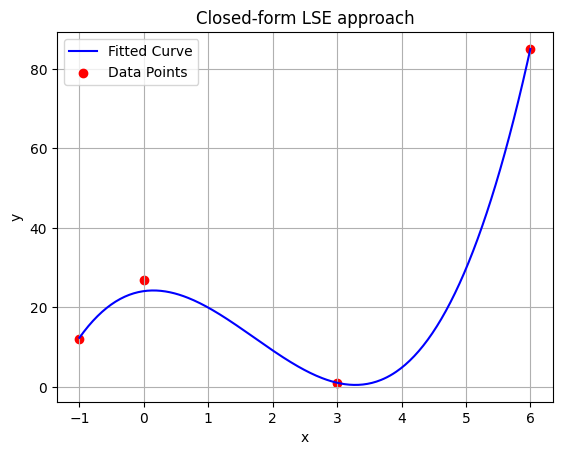

In [7]:
Error_Calculation_And_Diagram_Draw(A, w, Flatten_Y, degree, 'Closed-form LSE approach')

## 3. Steepest Descent Method

In [8]:
#需先執行前面第一個方塊 (有我寫的矩陣公式)
X = np.zeros((XY_collector.shape[0],degree+1))
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        X[i][j] = A[i]**j
w = np.zeros((degree+1,1))

In [9]:
def Steepest_Descent_Method(X,w,Flatten_Y,lr,iter_num,lambda_val):
    Flatten_Y = Flatten_Y.reshape(-1, 1)
    for i in range(iter_num):
        err = Matrix_Multiplication(X,w)-Flatten_Y #Y = Xw + b
        Grad_MSE_Loss = 2*Matrix_Multiplication(Matrix_Transpose(X),err) 
        #即Newton法的delta f(x), 2X.T x (X x w - Y) = 2X.T x X x w - 2X.T x Y
        Grad_L1_Regularization = lambda_val*np.sign(w) #原本Lasso是將其相加 -> 微分後變成只取方向
        Grad_Loss = Grad_MSE_Loss + Grad_L1_Regularization
        w = w - lr * Grad_Loss   
    return w

lr = 0.00001
w = Steepest_Descent_Method(X,w,Flatten_Y,lr,iter_num,lambda_val)
print(w)


[[ 5.83006589]
 [-3.27700037]
 [-1.24029464]
 [ 0.66314912]]


Equation:  5.830065891548497 x^0 + -3.277000365355208 x^1 + -1.2402946433547843 x^2 + 0.663149121235078 x^3
Mean Square Error: 118.5657


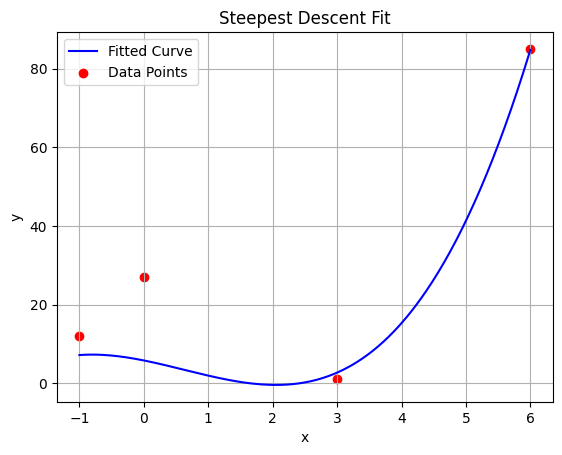

In [10]:
Error_Calculation_And_Diagram_Draw(A, w, Flatten_Y, degree, 'Steepest Descent Fit')

## 4. Newton Method

In [11]:
#需先執行前面第一個方塊 (有我寫的矩陣公式)
X = np.zeros((XY_collector.shape[0],degree+1))
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        X[i][j] = A[i]**j
w = np.zeros((degree+1,1))

In [12]:
def Newton_Method(X,w,Flatten_Y,iter_num):
    Flatten_Y = Flatten_Y.reshape(-1, 1)
    for i in range(iter_num):
        err = Matrix_Multiplication(X,w)-Flatten_Y 
        Grad_MSE_Loss = 2*Matrix_Multiplication(Matrix_Transpose(X),err) 
        HIfx = (1/2)*Matrix_Inversion(Matrix_Multiplication(Matrix_Transpose(X),X)) #Inverse of H(f(x))
        Grad_Loss = Matrix_Multiplication(HIfx, Grad_MSE_Loss) #Inverse of H(f(x)) x Grad_MSE_Loss
        w = w - Grad_Loss
    return w

w = Newton_Method(X,w,Flatten_Y,iter_num)
print(w)

[[27.        ]
 [ 3.92857143]
 [-9.3531746 ]
 [ 1.71825397]]


Equation:  27.0 x^0 + 3.928571428571427 x^1 + -9.353174603174603 x^2 + 1.7182539682539686 x^3
Mean Square Error: 0.0000


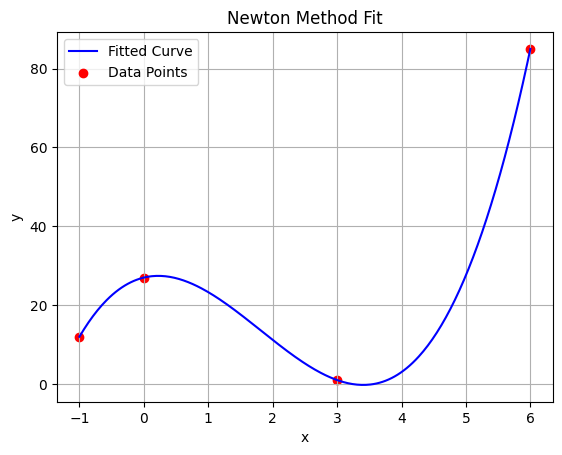

In [13]:
Error_Calculation_And_Diagram_Draw(A, w, Flatten_Y, degree, 'Newton Method Fit')